# WEEE — Notebook 1: Feature Engineering & Feature Analysis
### (E4, Zephyr, Muse ivmesinden MET/EE tahmini — çalışmanın feature mühendisliği ayağı)

**Bu notebook'un amacı**

Bu notebook, iki referans notebook'tan (`WEEE — Aktiviteden MET Tahmini (E4, Zephyr, Muse ivmesi)` ve
`WEEE_MET_EE_final`) türetilmiştir ve çalışmayı iki parçaya ayıran ilk parçadır:

1. **Notebook 1 (bu dosya)** → Feature engineering + feature analysis (exploratory).
2. **Notebook 2 (ayrı dosya)** → Model eğitimi + final LOSO değerlendirmesi.

**Kritik metodolojik karar:** Bu çalışmada ayrı bir *feature selection* adımı yoktur. Bu notebook'taki
korelasyon ve model-tabanlı importance analizleri **tamamen açıklayıcı/exploratory** amaçlıdır — makalenin
tartışma bölümünü beslemek için yapılır. Notebook 2, buradan hiçbir eleme kararı almadan, üç cihaz için de
**birebir aynı, tam zengin feature havuzuyla** modelleme yapacaktır. Gerekçe: veri setinde 17 özne var
(bazı hedeflerde 15-16'ya düşüyor); bu ölçekte LOSO fold'ları içinde ayrı feature seçimi yapmak sonuçları
fold'dan fold'a kararsızlaştırır ve zaten yüksek olan LOSO varyansının üstüne ek bir belirsizlik katmanı
bindirir. Ağaç tabanlı modeller (RF/GB/XGBoost) zaten split sırasında örtük feature ağırlıklandırması yapar;
elle dışarıdan seçim yapmanın kazancı belirsizken mühendislik/leakage riski kesindir.

**Bu notebook'ta düzeltilen asıl sorun feature seçimi değil, cihazlar arası adalettir.** Referans
notebook'larda E4'e diğer cihazlardan daha fazla feature veriliyordu (`OLD_EE` / `ee=True` bayrağı sadece
E4'te aktifti — bkz. aşağıdaki "Referans notebook'lardan doğrulanan bulgular"). Bu notebook, üç cihaza da
**birebir aynı sayıda ve aynı tanımda** 22 feature'lık bir havuz üretir.

**Notebook 2 ile arayüz (interface):**

| | |
|---|---|
| Çıktı dosyası | `windowed_feature_data.csv` / `.pkl` / `.parquet` |
| Satır birimi | pencere (window) — cihaz × özne × aktivite × pencere |
| Sabit kolonlar | `device`, `subject`, `activity`, `MET`, `EE`, `Weight`, `Height`, `BMI`, `Age`, `Sex`, `FFM` |
| Feature kolonları | 22 adet, üç cihazda da birebir aynı isim ve sayıda (aşağıda listeli) |
| Feature seçimi | **Yok.** Notebook 2 tüm feature kolonlarını olduğu gibi kullanır. |
| Ayrı çıktı | `feature_analysis_summary.pkl` — yalnızca raporlama/discussion amaçlı, modelleme girdisi DEĞİL |

---

## Referans notebook'lardan doğrulanan bulgular (bu notebook'un dayandığı gerçek yapı)

Notebook'u yazmadan önce iki referans notebook'un kodu ve **gerçek çalıştırma çıktıları** incelenmiştir:

1. **Veri yükleme:** `Study_Information.csv` (özne bazlı metadata + aktivite başlangıç zamanları + MET
   etiketleri), `Demographics.csv` (Weight/Height/BMI/Age/Sex/Fat), her özne klasöründe `E4/ACC.csv`,
   `ZEPHYR/*_Accel.csv`, `MUSE/acc.csv`, ve `VO2/` altında VO2Master verisi. Veri bir zip içinden
   `/content/weee_data`'ya açılıyor.
2. **Subject ID:** `Study_Information.csv`'de `Participant` kolonu (ör. `P01`, `P02`, ...).
3. **Activity:** `ACTS` listesiyle tanımlı 6 aktivite — `Sit, Stand, Cycle1, Cycle2, Run1, Run2` — her biri
   `Start_<aktivite>` zaman damgası ve `MET_<aktivite>` etiketiyle eşleşiyor.
4. **MET ve EE:** MET doğrudan `Study_Information.csv`'den okunuyor. EE, VO2Master ölçümünden türetiliyor:
   `EE (kcal/dk) = VO2[mL/min] / 1000 * 4.84`, aktivite penceresi içindeki VO2 örneklerinin ortalaması
   alınarak.
5. **Accelerometer kolonları:** E4 → başlıksız CSV, ilk satır t0, ikinci satır fs, sonrası ham ADC/64 (g
   birimine çevrilmiş) x,y,z. Zephyr → `Vertical, Lateral, Sagittal` kolonları + `Time` damgası. Muse →
   başlıksız `t,x,y,z`, zaten g biriminde, zaman damgaları düzensiz (sıralanıp fs veriden hesaplanıyor).
6. **Sampling rate:** E4 ≈ 32 Hz (dosyadan okunuyor), Zephyr = 100 Hz (sabit), Muse ≈ 44 Hz (veriden
   hesaplanan efektif fs). Üçü de birbirinden farklı.
7. **Mevcut window size:** `WEEE_MET_EE_final` içinde önce `WIN_A=4` sn ile çalışılmış, sonra **B1**
   bölümünde 4/30/60 sn karşılaştırılmış ve gerçek veriyle şu sonuç elde edilmiştir (çalıştırılmış
   notebook'un çıktısından, varsayım değil):
   ```
   pencere ortalaması (MAE):        normalize MAE (MAE/baseline):
   hedef       EE    MET             hedef        EE     MET   ortalama
   4        0.951  1.949             4        0.4068  0.3517   0.3792
   30       0.927  1.846             30       0.3964  0.3327   0.3646
   60       0.931  1.699             60       0.3981  0.3068   0.3525   <- seçilen
   Seçilen ortak pencere: 60 sn
   MET: en iyi 60 sn (MAE 1.699) | EE: en iyi 30 sn (MAE 0.927), 60 sn'de maliyet sadece +0.004
   ```
   Yani **60 saniyelik pencere, gerçek veri üzerinde MET ve EE için normalize edilmiş MAE'ye göre en iyi
   ortak seçenek olarak ampirik biçimde belirlenmiştir** — MET için zaten en iyisi, EE için ikinci en iyisi
   (maliyet ihmal edilebilir düzeyde). Bu yüzden bu notebook'ta `WINDOW_SIZE=60` **varsayım değil, referans
   notebook'ta gerçek veriyle doğrulanmış bir sonuç** olarak kullanılıyor; yine de kolayca değiştirilebilir
   bir parametre olarak bırakılmıştır (bkz. Bölüm 0). 60 sn'lik pencerelerle bile örneklem yeterliydi:
   `E4_bilek` 833, `Zephyr_gogus` 832, `Muse_kafa` 696 pencere (17/17/16 özne, NaN/inf yok).
8. **Mevcut feature extraction fonksiyonları:** `_f_old6` (6 feature: energy, shannon_entropy,
   max/min_amplitude, max/min_location — ham indeks, normalize edilmemiş), `_f_ee` (E4'e özel EE seti:
   enmo/std/rms/sma/dom_freq/spec_entropy), `_f_rich` (RICH/"zengin" set, 18 feature, üç cihazda da aynı
   kolonlarla hesaplanıyor).
9. **E4 vs Zephyr/Muse feature farkı (adaletsizliğin kaynağı):** `'eski'` feature setinde
   `cols_for('eski', kind) = OLD6 + (OLD_EE if kind=='E4' else [])` → **E4 12 feature, Zephyr/Muse sadece
   6 feature** alıyor (gerçek çalıştırma çıktısı: `eski: E4 12 | Zephyr 6 | Muse 6`). `'zengin'`
   (RICH) setinde bu adaletsizlik zaten giderilmiş durumda (`zengin: E4 18 | Zephyr 18 | Muse 18`) ancak
   RICH seti `min_amplitude, max_amplitude, min_location, max_location`'ı içermiyor. Bu notebook, RICH'in
   18 feature'ını OLD6'nın bu 4 feature'ıyla (normalize edilmiş location ile) birleştirerek **22
   feature'lık, üç cihazda da birebir eşit bir havuz** oluşturur.
10. **Mevcut LOSO implementasyonu:** `sklearn.model_selection.LeaveOneGroupOut`, grup = `subject`. Her
    fold'da model sadece training öznelerle `fit` ediliyor, tahminler segment (özne × aktivite) düzeyinde
    ortalanarak metrik hesaplanıyor (`seg_metrics`). Bu notebook'taki LOSO tabanlı feature importance
    analizi de aynı prensibi (fold-içi fit, held-out'a sızıntısız) kullanır — **ama seçim için değil,
    sadece daha güvenilir bir betimsel sıralama için.**
11. **Leakage riski kontrolü:** Referans koddaki `loso_single`/`loso_importance` fonksiyonlarında
    scaler/model her fold'da yalnızca `tr` (training) indeksleriyle fit ediliyor; test öznesi hiçbir
    aşamada (feature hesaplama hariç — feature'lar pencere içi istatistikler olduğu için özne-bağımsızdır)
    parametre tahminine girmiyor. Bu notebook da aynı disiplini korur: RF importance ve permutation
    importance LOSO fold'ları içinde, sadece training subjects ile hesaplanır.


## 0. Kurulum ve Parametreler

Bu notebook Google Colab / CPU ortamında çalışacak şekilde tasarlanmıştır. Ağır paralel CPU kullanımından
kaçınılır (`n_jobs` sınırlı tutulur). Tüm rastgelelik `SEED` ile sabitlenmiştir.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import glob, os, re, shutil, time, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.stats import pearsonr, spearmanr, kruskal

warnings.filterwarnings('ignore')

zips = glob.glob('/content/drive/MyDrive/PAWS/*.zip')
assert zips, "PAWS/*.zip bulunamadi -- Drive yolunu kontrol edin."
shutil.unpack_archive(zips[0], '/content/weee_data')
DATA_ROOT = os.path.dirname(glob.glob('/content/weee_data/**/Study_Information.csv', recursive=True)[0])
print("DATA_ROOT =", DATA_ROOT)


DATA_ROOT = /content/weee_data/dataset


In [3]:
# --- ANA AYARLAR (kolayca degistirilebilir) ---------------------------------
SEED         = 42
np.random.seed(SEED)

WINDOW_SIZE  = 60     # saniye. Referans notebook'ta (WEEE_MET_EE_final, Bolum B1) 4/30/60 sn
                       # gercek veriyle karsilastirilmis ve normalize edilmis MAE'ye gore 60 sn
                       # ortak pencere olarak secilmistir (bkz. ustteki markdown, madde 7).
                       # Varsayim DEGILDIR; yine de burada tek yerden degistirilebilir.
OVERLAP      = 0.5    # referans notebook'larla ayni: %50 ortusme.
MAX_OFF      = 300    # VO2 hizalamasinda kabul edilen en buyuk sapma (sn); asilirsa Start_Sit'e dusulur.
N_JOBS_RF    = 2       # RandomForest icin sinirli paralellik -- Colab CPU'sunu kilitlememek icin.
MIN_WIN_LEN  = 8       # bu sayidan kisa pencereler (ornek sayisi) atilir (referans notebook'la ayni esik).
MIN_VO2_COVERAGE = 0.6 # bir aktivite segmentinde gecerli VO2 orneginin, pencere suresine orani bu esigin
                       # altindaysa o segmentin EE'si steady-state'i temsil etmez sayilir ve NaN yapilir
                       # (makale: EE 5 dk pencereyle steady-state icin olculuyor; P03/P12 cycling, P16 running
                       # kismi VO2 kaybi belgeli). 0 yaparsan guard kapanir.

print(f"WINDOW_SIZE={WINDOW_SIZE} sn | OVERLAP={OVERLAP} | SEED={SEED} | N_JOBS_RF={N_JOBS_RF} | MIN_VO2_COVERAGE={MIN_VO2_COVERAGE}")


WINDOW_SIZE=60 sn | OVERLAP=0.5 | SEED=42 | N_JOBS_RF=2 | MIN_VO2_COVERAGE=0.6


## 1. Sinyal işleme yardımcı fonksiyonları

Bu fonksiyonlar iki referans notebook'ta da birebir aynı şekilde tanımlıydı; burada değiştirilmeden
taşınmıştır.


In [4]:
def clean(x):
    """Eksik ornekleri doldur -- ham sinyal (mad hesaplamasinda da kullaniliyor), NaN sizmamali."""
    return np.nan_to_num(pd.Series(x, dtype='float64').interpolate(limit_direction='both').to_numpy())

def bandpass(x, fs, low, high, order=4):
    nyq = fs / 2.0
    high = min(high, nyq * 0.95)
    b, a = butter(order, [low/nyq, high/nyq], btype='bandpass')
    return filtfilt(b, a, clean(x))

def mag3(x, y, z):
    return np.sqrt(x**2 + y**2 + z**2)

def segment_signal(sig, fs, win_sec, overlap=0.5):
    """Sinyali win_sec uzunlugunda, overlap oraninda ortusen pencerelere boler."""
    sig = np.asarray(sig)
    w = int(round(win_sec * fs))
    step = max(1, int(round(w * (1 - overlap))))
    return [sig[s:s+w] for s in range(0, len(sig) - w + 1, step)]

print("hazir")


hazir


## 2. Ortak ve adil feature havuzu (22 feature, tüm cihazlarda birebir aynı)

Aşağıdaki 22 feature, **üç cihaz için de aynı kolon isimleriyle ve aynı matematiksel tanımla** hesaplanır.
Bu, referans notebook'lardaki `_f_rich` (RICH/"zengin" set, 18 feature) ile `_f_old6`'nın
(`min_amplitude, max_amplitude, min_location, max_location`) birleşimidir:

| # | Feature | Tanım | Kaynak sinyal |
|---|---|---|---|
| 1 | `mad` | ortalama mutlak sapma, `mean(\|r - mean(r)\|)` | ham (bandpass'siz) manyitüd |
| 2 | `energy` | ortalama enerji, `mean(w²)` | bandpass |
| 3 | `std` | standart sapma | bandpass |
| 4 | `rms` | RMS | bandpass |
| 5 | `sma` | ortalama mutlak değer, `mean(\|w\|)` | bandpass |
| 6 | `shannon_entropy` | histogram tabanlı Shannon entropisi (32 bin) | bandpass |
| 7 | `dom_freq` | FFT'de en yüksek güce sahip frekans | bandpass |
| 8 | `spec_entropy` | normalize güç spektrumunun Shannon entropisi | bandpass |
| 9-11 | `p10, p50, p90` | 10/50/90. persentiller | bandpass |
| 12 | `iqr` | `p90 - p10` | bandpass |
| 13 | `rmssd` | ardışık farkların RMS'i | bandpass |
| 14 | `zcr` | sıfır geçiş oranı | bandpass |
| 15 | `autocorr1` | lag-1 normalize otokorelasyon | bandpass |
| 16-18 | `bp_low, bp_mid, bp_high` | 0.5–2 / 2–5 / 5–12 Hz bantlarındaki güç oranı | bandpass |
| 19-20 | `min_amplitude, max_amplitude` | pencere içi min/max değer | bandpass |
| 21-22 | `min_location, max_location` | min/max'ın pencere içindeki **normalize** konumu | bandpass |

**`min_location` / `max_location` normalizasyonu (zorunlu, referans koddan farkı):** Referans
notebook'ta bu iki feature ham örnek indeksi (`argmin`, `argmax`) olarak saklanıyordu. E4 (~32 Hz), Zephyr
(100 Hz) ve Muse (~44 Hz) farklı örnekleme hızlarına sahip olduğu için aynı 60 saniyelik pencere farklı
sayıda örnekten oluşur (E4 ≈1920, Zephyr ≈6000, Muse ≈2640 örnek); ham indeks bu yüzden cihazlar arasında
doğrudan karşılaştırılamaz — yalnızca örnekleme hızı farkını yansıtır. Bu notebook'ta
`location_normalized = index / len(window)` (0–1 arası) kullanılır.

**`energy` tanımı üzerine not:** RICH set'te `energy`, `sum(w²)` değil `mean(w²)` olarak tanımlanmıştır
(referans kodda `_f_rich` içinde `sum(w**2)/n`). Bu kasıtlı bir tercih olarak korunmuştur: ham toplam
kullanılsaydı, aynı 60 saniyelik pencerede Zephyr (100 Hz, ~6000 örnek) otomatik olarak E4'ten (~32 Hz,
~1920 örnek) çok daha yüksek "energy" değeri alırdı — bu sadece örnekleme hızı farkının bir artefaktı olur,
sinyalin gerçek genlik/aktivite düzeyini yansıtmazdı. `mean(w²)` kullanmak bu artefaktı ortadan kaldırır.

**`mad` neden `enmo` yerine kullanıldı:** Referans notebook'un `'eski'` ve E4'e-özel EE setinde `enmo`
(`mean(max(r - 1.0, 0))`) kullanılıyordu; bu, sinyalin durağan halde ~1g etrafında olduğu varsayımına
dayanır ve yalnızca E4 için anlamlı bir kalibrasyon varsayımıdır. `'simetrik'` ve `'zengin'` setlerinde
referans notebook zaten `enmo` yerine `mad`'a geçmiştir (`SYM_EE = ["mad", "std", ...]`) çünkü `mad`
herhangi bir 1g-referans varsayımı gerektirmez ve üç cihazda da aynı şekilde hesaplanabilir. Bu notebook bu
tercihi korur.


In [5]:
FEATURE_POOL = [
    "mad", "energy", "std", "rms", "sma", "shannon_entropy", "dom_freq", "spec_entropy",
    "p10", "p50", "p90", "p10_90_range", "rmssd", "zcr", "autocorr1",
    "bp_low", "bp_mid", "bp_high",
    "min_amplitude", "max_amplitude", "min_location", "max_location",
]
assert len(FEATURE_POOL) == 22
print(f"Feature havuzu: {len(FEATURE_POOL)} feature (uc cihazda da ayni)")
print(FEATURE_POOL)


Feature havuzu: 22 feature (uc cihazda da ayni)
['mad', 'energy', 'std', 'rms', 'sma', 'shannon_entropy', 'dom_freq', 'spec_entropy', 'p10', 'p50', 'p90', 'p10_90_range', 'rmssd', 'zcr', 'autocorr1', 'bp_low', 'bp_mid', 'bp_high', 'min_amplitude', 'max_amplitude', 'min_location', 'max_location']


In [6]:
def shannon_entropy(w, bins=32):
    h, _ = np.histogram(w, bins=bins)
    p = h.astype(float)
    p = p[p > 0]
    if p.size == 0:
        return 0.0
    p /= p.sum()
    return float(-np.sum(p * np.log2(p)))

def _spectrum(w, fs):
    """FFT tabanli guc spektrumu. dom = baskin frekans, se = spektral entropi,
    p/fr = guc/frekans dizileri (bant hesaplarinda kullanilir), tot = toplam guc."""
    s = np.abs(np.fft.rfft(w))
    fr = np.fft.rfftfreq(len(w), 1 / fs)
    dom = float(fr[1:][np.argmax(s[1:])]) if len(s) > 1 else 0.0
    p = s ** 2
    tot = p.sum() + 1e-12
    pn = p / tot
    se = float(-np.sum(pn * np.log2(pn + 1e-12)))
    return dom, se, p, fr, tot

def extract_features(wbp, wraw, fs):
    """22 feature'i FEATURE_POOL sirasiyla dondurur.
    wbp  : bandpass filtrelenmis manyitud penceresi
    wraw : ham (filtresiz) manyitud penceresi -- sadece 'mad' icin kullanilir
    fs   : cihaza ozgu ornekleme hizi (Hz)
    """
    w = np.asarray(wbp, dtype=float)
    r = np.asarray(wraw, dtype=float)
    n = len(w)

    mad = float(np.mean(np.abs(r - r.mean())))
    energy = float(np.mean(w ** 2))
    std = float(w.std())
    rms = float(np.sqrt(np.mean(w ** 2)))
    sma = float(np.mean(np.abs(w)))
    se = shannon_entropy(w)
    dom, spec_ent, p, fr, tot = _spectrum(w, fs)

    p10, p50, p90 = np.percentile(w, [10, 50, 90])
    p10_90_range = float(p90 - p10)   # 10-90 persentil acikligi -- klasik IQR (25-75) DEGIL

    if n > 1:
        dv = np.diff(w)
        rmssd = float(np.sqrt(np.mean(dv ** 2)))
        zcr = float(np.mean(np.diff(np.sign(w - w.mean())) != 0))
        wc = w - w.mean()
        den = float(np.sum(wc ** 2)) + 1e-12
        ac1 = float(np.sum(wc[:-1] * wc[1:]) / den)
    else:
        rmssd = zcr = ac1 = 0.0

    band = lambda lo, hi: float(p[(fr >= lo) & (fr < hi)].sum() / tot)
    bp_low, bp_mid, bp_high = band(0.5, 2), band(2, 5), band(5, 12)

    min_amp, max_amp = float(w.min()), float(w.max())
    min_loc = float(np.argmin(w)) / n if n > 0 else np.nan
    max_loc = float(np.argmax(w)) / n if n > 0 else np.nan

    return [mad, energy, std, rms, sma, se, dom, spec_ent,
            float(p10), float(p50), float(p90), p10_90_range, rmssd, zcr, ac1,
            bp_low, bp_mid, bp_high, min_amp, max_amp, min_loc, max_loc]

# hizli dogrulama -- GERCEKCI girdi: 'wbp' gercekte mag3(xb,yb,zb), yani her zaman >= 0.
# Bu yuzden testi de negatif-olmayan bir manyitud penceresiyle yapiyoruz; boylece
# zcr'nin sign(w) yerine sign(w - w.mean()) ile dogru hesaplandigini fiilen dogruluyoruz.
_rng = np.random.RandomState(0)
_axis = lambda: _rng.randn(int(60 * 32))
_dummy = mag3(_axis(), _axis(), _axis())          # >= 0, gercek wbp gibi
_out = extract_features(_dummy, _dummy, 32.0)
_feat = dict(zip(FEATURE_POOL, _out))
assert len(_out) == len(FEATURE_POOL), "extract_features cikti sayisi FEATURE_POOL ile uyusmuyor!"
assert _feat['zcr'] > 0, "zcr negatif-olmayan sinyalde 0 cikti -- sign(w) degil sign(w - w.mean()) kullanilmali!"
print("extract_features dogrulandi:", {k: round(v, 4) for k, v in _feat.items()})


extract_features dogrulandi: {'mad': 0.5309, 'energy': 2.9202, 'std': 0.6641, 'rms': 1.7089, 'sma': 1.5746, 'shannon_entropy': 4.2596, 'dom_freq': 11.9, 'spec_entropy': 1.1673, 'p10': 0.7409, 'p50': 1.5355, 'p90': 2.4561, 'p10_90_range': 1.7153, 'rmssd': 0.9581, 'zcr': 0.5128, 'autocorr1': -0.041, 'bp_low': 0.0064, 'bp_mid': 0.0137, 'bp_high': 0.039, 'min_amplitude': 0.0879, 'max_amplitude': 4.5339, 'min_location': 0.3417, 'max_location': 0.624}


### Cihazlar arası ölçüm farklılıkları ve dikkat noktaları (yorumlama için)

Feature'lar üç cihazda da aynı formülle hesaplanıyor olsa da, cihazların donanımsal farkları bazı
feature'ların **doğrudan sayısal karşılaştırmasını** güçleştirir. Bunlar eleme gerekçesi değildir —
sadece Notebook 1/2'deki tabloları yorumlarken akılda tutulması gereken noktalardır:

- **`dom_freq`, `bp_low/bp_mid/bp_high`:** Bandpass filtre üst kesimi cihaza göre farklıdır (E4/Muse
  0.5–12 Hz, Zephyr 0.5–20 Hz). `bp_low+bp_mid+bp_high` bantları hep 0.5–12 Hz'i kapsadığı için, üst
  kesimi 12 Hz olan E4/Muse'da bu üç bant toplam gücün neredeyse tamamını açıklarken, Zephyr'de
  12–20 Hz aralığındaki güç hiçbir banda girmez ve toplam normalize güçten (`tot`) düşülmez. Bu, aynı üç
  bant oranının Zephyr için E4/Muse'a göre sistematik olarak daha düşük çıkmasına yol açabilir.
- **`spec_entropy`:** Zephyr'in geçirgen bandı (0.5–20 Hz) E4/Muse'unkinden (0.5–12 Hz) daha geniş
  olduğu için, aynı pencere uzunluğunda Zephyr'in spektrumunda daha fazla frekans bin'i bulunur; bu da
  spektral entropiyi sistematik olarak yukarı çekebilir.
- **`min_location` / `max_location`:** Normalize edilmiş olsalar bile (0–1), farklı örnekleme hızları
  aynı 60 saniyelik pencerede farklı çözünürlükte (E4 ~1920, Zephyr ~6000, Muse ~2640 örnek) konum tahmini
  anlamına gelir; Zephyr'deki konum tahmini örnek bazında daha "ince" olacaktır.
- **`mad` ve genlik-tabanlı feature'lar (`min_amplitude`, `max_amplitude`, `std`, `rms`, `sma`, `p10/50/90`,
  `p10_90_range` (10–90 persentil açıklığı; klasik IQR değil), `rmssd`):** Cihazların ham sinyal kalibrasyonu farklıdır — E4 g cinsine çevrilmiş (`/64`), Muse
  zaten g cinsinde, Zephyr'in ham ekseni (`Vertical/Lateral/Sagittal`) doğrudan kullanılıyor ve g
  cinsinden olduğu ayrıca doğrulanmamıştır. Bu nedenle genlik-tabanlı feature'ların mutlak ölçeği cihazlar
  arasında birebir karşılaştırılabilir olmayabilir; **göreli** (aktiviteler arası sıralama, korelasyon)
  karşılaştırmalar daha güvenlidir.
- **`shannon_entropy`, `zcr`, `autocorr1`, `rmssd`:** Bunlar örnek sayısına daha az duyarlıdır (oran/normalize
  istatistikler) ancak yine de düşük örnek sayısında (E4'ün 1920 örneği) tahmin varyansı, yüksek örnek
  sayısına (Zephyr'in 6000 örneği) göre bir miktar daha yüksek olabilir.

Bu farklılıklar Adım 2–4'teki karşılaştırmalı tablolarda **açıkça not düşülerek** raporlanacaktır.


## 3. Study_Information, aktivite aralıkları ve MET

Aktivite tanımları ve MET etiketleri referans notebook'larla birebir aynıdır.


In [7]:
ACTS = [
    ('Sit',    'Start_Sit',    'MET_Sit'),
    ('Stand',  'Start_Stand',  'MET_Stand'),
    ('Cycle1', 'Start_Cycle1', 'MET_Cycle1'),
    ('Cycle2', 'Start_Cycle2', 'MET_Cycle2'),
    ('Run1',   'Start_Run1',   'MET_Run1'),
    ('Run2',   'Start_Run2',   'MET_Run2'),
]
ACT_ORDER = [a for a, _, _ in ACTS]

def to_unix(s):
    return pd.Timestamp(str(s).strip()).tz_localize('UTC').timestamp()

def to_num(x):
    try:
        return float(str(x).strip())
    except Exception:
        return np.nan

def activity_segments(r):
    """Bir ozne satirindan (Study_Information) 6 aktivite arali cikarir.
    Her aktivite bir sonrakinin baslangicina ya da en fazla 300 sn'ye kadar surer."""
    st = [to_unix(r[c]) for _, c, _ in ACTS]
    out = []
    for i, (nm, sc, mc) in enumerate(ACTS):
        a = st[i]
        nxt = st[i + 1] if i + 1 < len(st) else a + 300
        b = min(nxt, a + 300)
        out.append(dict(activity=nm, MET=to_num(r[mc]), start=a, end=b, valid=b > a))
    return out

SI = pd.read_csv(os.path.join(DATA_ROOT, 'Study_Information.csv'))
print("ozne sayisi:", len(SI), "|", SI['Participant'].tolist())


ozne sayisi: 17 | ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17']


## 4. Cihaz okuyucular ve pencereli feature tablosu kurma

Üç cihaz için de **aynı `WINDOW_SIZE`, aynı `OVERLAP` ve aynı `FEATURE_POOL`** kullanılır — cihazlar
arasında hiçbir asimetri yoktur (referans notebook'taki `ee=True`/`OLD_EE` bayrağının aksine). Bandpass
filtre aralıkları (`band`) referans notebook'lardaki cihaz-özgü değerlerle aynıdır (E4/Muse 0.5–12 Hz,
Zephyr 0.5–20 Hz) — bunlar donanımın gürültü karakteristiğine göre belirlenmiş cihaz-özgü ayarlardır, feature
sayısı/seçimiyle ilgisi yoktur.


In [8]:
def load_device(path, kind):
    if kind == 'E4':
        raw = pd.read_csv(path, header=None)
        t0 = float(raw.iloc[0, 0]); fs = float(raw.iloc[1, 0])
        d = raw.iloc[2:].reset_index(drop=True).astype(float) / 64.0
        return d.iloc[:, 0].values, d.iloc[:, 1].values, d.iloc[:, 2].values, fs, t0 + np.arange(len(d)) / fs
    if kind == 'ZEPHYR':
        z = pd.read_csv(path)
        tt = pd.to_datetime(z['Time'], format='%d/%m/%Y %H:%M:%S.%f').dt.tz_localize('UTC').map(lambda v: v.timestamp()).values
        return z['Vertical'].values, z['Lateral'].values, z['Sagittal'].values, 100.0, tt
    # MUSE
    d = pd.read_csv(path, header=None)
    d.columns = ['t', 'x', 'y', 'z']
    d = d.sort_values('t').reset_index(drop=True)
    tt = d['t'].values
    span = tt[-1] - tt[0]
    fs = len(d) / span if span > 0 else 50.0
    return d['x'].values, d['y'].values, d['z'].values, fs, tt

DEV = {
    'E4':     dict(pat='*/E4/ACC.csv',         band=(0.5, 12.0)),
    'ZEPHYR': dict(pat='*/ZEPHYR/*_Accel.csv', band=(0.5, 20.0)),
    'MUSE':   dict(pat='*/MUSE/acc.csv',       band=(0.5, 12.0)),
}
DEVICE_LABELS = {'E4': 'E4_bilek', 'ZEPHYR': 'Zephyr_gogus', 'MUSE': 'Muse_kafa'}

_SIGNAL_CACHE = {}
_TABLE_CACHE = {}

def get_signals(kind):
    """Cihaz basina ham+bandpass sinyalleri onbellekler (tekrar tekrar dosya okumamak icin)."""
    if kind in _SIGNAL_CACHE:
        return _SIGNAL_CACHE[kind]
    lo, hi = DEV[kind]['band']
    out = []
    for path in sorted(glob.glob(os.path.join(DATA_ROOT, DEV[kind]['pat']))):
        pid = 'P%02d' % int(''.join(filter(str.isdigit, path.split(os.sep)[-3])))
        if len(SI[SI['Participant'] == pid]) == 0:
            continue
        try:
            x, y, z, fs, tt = load_device(path, kind)
            x, y, z = clean(x), clean(y), clean(z)
            xb, yb, zb = bandpass(x, fs, lo, hi), bandpass(y, fs, lo, hi), bandpass(z, fs, lo, hi)
            out.append((pid, xb, yb, zb, mag3(xb, yb, zb), mag3(x, y, z), fs, tt))
        except Exception as e:
            print('  atlandi', pid, kind, e)
    _SIGNAL_CACHE[kind] = out
    return out

def build_feature_table(kind):
    """Bir cihaz icin FEATURE_POOL'daki 22 feature'i, WINDOW_SIZE/OVERLAP ile pencerelenmis
    her segment icin hesaplar. Sonuc onbelleklenir (ayni parametrelerle tekrar cagrilirsa
    yeniden hesaplama yapilmaz)."""
    key = (kind, WINDOW_SIZE, OVERLAP)
    if key in _TABLE_CACHE:
        return _TABLE_CACHE[key].copy()

    rows = []
    for pid, xb, yb, zb, mbp, mraw, fs, tt in get_signals(kind):
        r = SI[SI['Participant'] == pid].iloc[0]
        for s in activity_segments(r):
            if not s['valid']:
                continue
            m = (tt >= s['start']) & (tt < s['end'])
            wb_list = segment_signal(mbp[m], fs, WINDOW_SIZE, OVERLAP)
            wr_list = segment_signal(mraw[m], fs, WINDOW_SIZE, OVERLAP)
            for wb, wr in zip(wb_list, wr_list):
                if len(wb) < MIN_WIN_LEN:
                    continue
                feats = extract_features(wb, wr, fs)
                row = dict(zip(FEATURE_POOL, feats))
                row.update(MET=s['MET'], activity=s['activity'], subject=pid)
                rows.append(row)

    t = pd.DataFrame(rows)
    t[FEATURE_POOL] = t[FEATURE_POOL].replace([np.inf, -np.inf], np.nan)
    bad = int(t[FEATURE_POOL].isna().any(axis=1).sum())
    if bad:
        print(f"    [{kind} {WINDOW_SIZE}sn] {bad} gecersiz (NaN/inf) pencere atildi")
    t = t.dropna(subset=FEATURE_POOL).reset_index(drop=True)
    _TABLE_CACHE[key] = t
    return t.copy()

print("hazir")


hazir


## 5. EE hedefi: VO2 tabanlı enerji harcaması ve hizalama

`EE (kcal/dk) = VO2[mL/min] / 1000 * 4.84`. VO2Master saatinin çalışma başlangıcı, `Study_Information`'daki
`Start_Sit` zaman damgasıyla hizalanır; mümkünse `VO2/Details.txt` içindeki mutlak başlangıç saati
kullanılır (referans notebook'taki mantıkla birebir aynı), sapma `MAX_OFF` saniyeyi aşarsa `Start_Sit`'e
düşülür. Bu adım feature mühendisliğinin bir parçası değildir ama Notebook 2'nin ihtiyaç duyduğu `EE`
etiketini üretir; bu yüzden burada, referans koddan sadık şekilde taşınmıştır.


In [9]:
VO2_CANDIDATES = ['VO2MasterUnit-Data.csv', 'DataAverage.csv']

def vo2_folder(pid):
    for fold in glob.glob(os.path.join(DATA_ROOT, '*', 'VO2')):
        if 'P%02d' % int(''.join(filter(str.isdigit, fold.split(os.sep)[-2]))) == pid:
            return fold
    return None

def find_vo2(pid):
    fold = vo2_folder(pid)
    if fold is None:
        return None
    for name in VO2_CANDIDATES:
        p = os.path.join(fold, name)
        if os.path.exists(p):
            return p
    csvs = [c for c in sorted(glob.glob(os.path.join(fold, '*.csv')))
            if 'Diagnostic' not in c and 'Session' not in c and 'HeartRate' not in c]
    return csvs[0] if csvs else None

def parse_details_start(pid, ref):
    for f in glob.glob(os.path.join(DATA_ROOT, '*', 'VO2', 'Details.txt')):
        if 'P%02d' % int(''.join(filter(str.isdigit, f.split(os.sep)[-3]))) != pid:
            continue
        txt = open(f, errors='ignore').read()
        try:
            date = re.search(r'Workout Date:\s*(.+)', txt).group(1).strip()
            tm = re.search(r'Start Time:\s*(.+)', txt).group(1).strip()
            m = re.search(r'Time Zone:\s*(.+)', txt)
            tz = m.group(1).strip() if m else 'UTC'
        except AttributeError:
            return None
        c = []
        for fmt in ('%d/%m/%Y %I:%M:%S %p', '%m/%d/%Y %I:%M:%S %p'):
            try:
                c.append(pd.to_datetime(f"{date} {tm}", format=fmt).tz_localize(tz).tz_convert('UTC').timestamp())
            except Exception:
                pass
        if c:
            return min(c, key=lambda u: abs(u - ref))
    return None

def vo2_unix(v, used):
    """Zaman ekseni: mutlak 'Time' kolonu varsa o kullanilir, yoksa Details.txt+Time[s]."""
    if 'Time' in v.columns:
        t = pd.to_datetime(v['Time'], errors='coerce')
        if t.notna().mean() > 0.9:
            return t.dt.tz_localize('UTC').map(lambda x: x.timestamp()).values, 'mutlak Time'
    return used + v['Time[s]'].values, 'Details+Time[s]'

EE_MAP = {}
COVER_MAP = {}
_align_rows = []
for _, r in SI.iterrows():
    pid = r['Participant']
    path = find_vo2(pid)
    if path is None:
        _align_rows.append((pid, np.nan, 'VO2 yok', '-'))
        continue
    ref = to_unix(r['Start_Sit'])
    start = parse_details_start(pid, ref)
    if start is None:
        used, off, durum = ref, np.nan, 'Details okunamadi'
    else:
        off = round(start - ref, 1)
        if abs(off) <= 5:
            used, durum = start, 'ok'
        elif abs(off) <= MAX_OFF:
            used, durum = start, 'kucuk sapma'
        else:
            used, durum = ref, 'DUZELTILDI -> Start_Sit'
    v = pd.read_csv(path)
    v.columns = v.columns.str.strip()
    if 'VO2[mL/min]' not in v.columns:
        _align_rows.append((pid, off, 'VO2[mL/min] kolonu yok', '-'))
        continue
    v = v[v['VO2[mL/min]'] > 0].copy()  # VO2=0 satirlari gecersiz olcum, atilir
    u, yontem = vo2_unix(v, used)
    v['unix'] = u
    v['ee'] = v['VO2[mL/min]'] / 1000.0 * 4.84
    _align_rows.append((pid, off, durum, yontem))
    # Kapsama = ZAMAN-ARALIGI kapsamasi: VO2 ornekleri pencere suresince bastan sona yayiliyor mu?
    # Ornek YOGUNLUGU (adet/sn) kullanmiyoruz, cunku VO2[mL/min] nefes basina anlamlidir ve nefes
    # hizi dinlenmede yavas / egzersizde hizlidir -> yogunluk dinlenme segmentlerini yanlis eler.
    # Aralik kapsamasi nefes hizindan bagimsizdir; sadece kaydin GERCEKTEN eksik oldugu ( or. VO2
    # kaydi son aktiviteden once bitmis) segmentleri yakalar.
    for s in activity_segments(r):
        w = v[(v['unix'] >= s['start']) & (v['unix'] < s['end'])]
        dur = max(s['end'] - s['start'], 1e-9)
        if len(w) >= 2:
            cover = float(w['unix'].max() - w['unix'].min()) / dur   # ornekler penceenin ne kadarini kapsiyor
        else:
            cover = 0.0
        COVER_MAP[(pid, s['activity'])] = round(float(cover), 2)
        ee = w['ee'].mean() if len(w) else np.nan
        if cover < MIN_VO2_COVERAGE:
            ee = np.nan        # kismi/eksik VO2 -> steady-state degil, EE gecersiz sayilir
        EE_MAP[(pid, s['activity'])] = ee

align_tab = pd.DataFrame(_align_rows, columns=['subject', 'offset_sn', 'durum', 'zaman_ekseni'])
print("=== VO2 hizalama ozeti ===")
print(align_tab.to_string(index=False))
print("\nEE etiketli segment:", sum(x == x for x in EE_MAP.values()), "/", len(EE_MAP),
      "| EE'si olan ozne:", len({k[0] for k, v in EE_MAP.items() if v == v}))

# dusuk VO2 kapsamasi nedeniyle EE'si gecersiz sayilan segmentleri raporla (seffaflik icin)
_lowcov = sorted([(p, a, COVER_MAP[(p, a)]) for (p, a) in COVER_MAP
                  if COVER_MAP[(p, a)] < MIN_VO2_COVERAGE])
if _lowcov:
    print(f"\n[!] VO2 kapsamasi < {MIN_VO2_COVERAGE:.0%} -> EE'si gecersiz sayilan segmentler:")
    print(pd.DataFrame(_lowcov, columns=['subject', 'activity', 'kapsama']).to_string(index=False))
else:
    print(f"\nTum segmentlerde VO2 kapsamasi >= {MIN_VO2_COVERAGE:.0%}.")

# --- EE hizalama akil-saglamasi (ozellikle Details okunamayan, 'mutlak Time' ile hizalanan ozneler) ---
# Dogru hizalanmis bir oznede: Sit segmenti dinlenime yakin (~1-2 kcal/dk) olmali ve aktivite-ici EE,
# protokol MET'i ile guclu pozitif korelasyon (rho ~ +1) gostermeli. Dusuk/negatif korelasyon ya da
# asiri yuksek Sit_EE, o oznede zaman hizalamasinin bozuk oldugunu isaret eder.
_axis_method = {pid: ax for pid, off, durum, ax in _align_rows}
_met_by_act = {}
for _, r in SI.iterrows():
    for s in activity_segments(r):
        _met_by_act[(r['Participant'], s['activity'])] = s['MET']
_rows_chk = []
for pid in SI['Participant']:
    prs = [(_met_by_act.get((pid, a)), EE_MAP.get((pid, a))) for a in ACT_ORDER]
    prs = [(m, e) for m, e in prs if (m == m) and (e == e)]
    sit_ee = EE_MAP.get((pid, 'Sit'), np.nan)
    rho = spearmanr(*zip(*prs)).correlation if len(prs) >= 3 else np.nan
    uyari = []
    if _axis_method.get(pid) == 'mutlak Time':
        uyari.append('DOGRULANMADI(mutlak Time)')
    if (rho == rho) and rho < 0.5:
        uyari.append('dusuk MET-EE rho')
    if (sit_ee == sit_ee) and sit_ee > 3.0:
        uyari.append('Sit_EE yuksek')
    _rows_chk.append((pid, _axis_method.get(pid, '-'),
                      round(sit_ee, 2) if sit_ee == sit_ee else np.nan,
                      round(rho, 2) if rho == rho else np.nan, len(prs), ' | '.join(uyari)))
_ee_check = pd.DataFrame(_rows_chk,
    columns=['subject', 'zaman_ekseni', 'Sit_EE', 'MET_EE_rho', 'n_akt', 'uyari'])
print("\n=== EE hizalama akil-saglamasi (BEKLENEN: Sit_EE ~1-2 kcal/dk, MET_EE_rho ~ +1) ===")
print(_ee_check.to_string(index=False))


=== VO2 hizalama ozeti ===
subject  offset_sn                   durum    zaman_ekseni
    P01        0.0                      ok Details+Time[s]
    P02        NaN       Details okunamadi     mutlak Time
    P03        NaN       Details okunamadi     mutlak Time
    P04        0.0                      ok Details+Time[s]
    P05        0.0                      ok Details+Time[s]
    P06        0.0                      ok Details+Time[s]
    P07        0.0                      ok Details+Time[s]
    P08        0.0                      ok Details+Time[s]
    P09        0.0                      ok Details+Time[s]
    P10     4083.0 DUZELTILDI -> Start_Sit Details+Time[s]
    P11        0.0                      ok Details+Time[s]
    P12        NaN       Details okunamadi     mutlak Time
    P13        0.0                      ok Details+Time[s]
    P14        0.0                      ok Details+Time[s]
    P15        0.0                      ok Details+Time[s]
    P16        NaN       Deta

## 6. Demografik metadata (Weight / Height / BMI / Age / Sex / FFM)

Bunlar model feature'ı değil, **metadata** kolonlarıdır — Notebook 2'nin isterse kullanabileceği ek
bağlamdır (FEATURE_POOL'a dahil değildir).


In [10]:
demo_path = glob.glob(os.path.join(DATA_ROOT, '**', 'Demographics.csv'), recursive=True)[0]
demo = pd.read_csv(demo_path)
demo['Sex'] = (demo['Gender'].astype(str).str.upper() == 'M').astype(int)
demo['FFM'] = demo['Weight'] * (1 - demo['Fat'] / 100.0)
DEMO = demo.set_index('Participant')[['Weight', 'Height', 'BMI', 'Age', 'Sex', 'FFM']]
METADATA_COLS = list(DEMO.columns)
print(f"Demografik tablo: {DEMO.shape[0]} ozne, eksik deger {DEMO.isna().sum().sum()}")
DEMO.head()


Demografik tablo: 17 ozne, eksik deger 0


,Weight,Height,BMI,Age,Sex,FFM
Participant,,,,,,
P01,70.6,166,24.7,29,0,47.302
P02,77.0,173,25.7,26,1,61.600
P03,61.0,172,20.6,26,0,46.970
P04,81.5,175,26.6,27,1,67.645
P05,66.0,163,24.8,33,0,45.540


## 7. Tabloları kur ve uçuş öncesi kontrol

Her cihaz için pencereli feature tablosu (`build_feature_table`) `EE` etiketi ve demografik metadata ile
birleştirilir (`attach`). `make_devices()` üç cihazı da aynı `WINDOW_SIZE`/`FEATURE_POOL` ile üretir —
hiçbir cihaz diğerinden farklı sayıda ya da farklı tanımda feature almaz.


In [11]:
def attach(d):
    d = d.copy()
    d['EE'] = [EE_MAP.get((s, a), np.nan) for s, a in zip(d['subject'], d['activity'])]
    for c in DEMO.columns:
        d[c] = d['subject'].map(DEMO[c])
    return d

def make_devices():
    return {
        'E4_bilek':     attach(build_feature_table('E4')),
        'Zephyr_gogus': attach(build_feature_table('ZEPHYR')),
        'Muse_kafa':    attach(build_feature_table('MUSE')),
    }

t0 = time.time()
DEVICES = make_devices()
print(f"tablolar kuruldu ({time.time()-t0:.0f} sn)")


tablolar kuruldu (62 sn)


In [12]:
def preflight(devices):
    """Feature sayisi/isimlerinin ucu cihazda da ayni oldugunu, NaN/inf olmadigini,
    ve EE etiketi olan ama tabloya girmeyen ozne olup olmadigini kontrol eder."""
    ok = True
    ref_cols = None
    for name, t in devices.items():
        cols_present = [c for c in FEATURE_POOL if c in t.columns]
        if len(cols_present) != len(FEATURE_POOL):
            print(f"  [{name}] EKSIK FEATURE KOLONU! beklenen {len(FEATURE_POOL)}, bulunan {len(cols_present)}")
            ok = False
        if ref_cols is None:
            ref_cols = cols_present
        elif cols_present != ref_cols:
            print(f"  [{name}] feature kolon SIRASI/ISMI diger cihazlarla uyusmuyor!")
            ok = False

        nan = int(t[FEATURE_POOL].isna().sum().sum())
        inf = int(np.isinf(t[FEATURE_POOL].to_numpy()).sum())
        dnan = int(t[METADATA_COLS].isna().sum().sum())
        flag = '' if (nan == 0 and inf == 0) else '   <-- SORUN'
        print(f"  {name:14} satir {len(t):6} | feature {len(cols_present):2} | NaN {nan} | inf {inf} | "
              f"demo-NaN {dnan} | ozne {t['subject'].nunique():2} | EE'li satir {int(t['EE'].notna().sum()):5}{flag}")
        if nan or inf:
            ok = False

    ee_lbl = {k[0] for k, v in EE_MAP.items() if v == v}
    for name, t in devices.items():
        inmod = set(t.loc[t['EE'].notna(), 'subject'])
        drop = sorted(ee_lbl - inmod)
        if drop:
            print(f"  NOT [{name}] EE etiketi olup tabloya girmeyen ozne: {drop} "
                  f"-> {len(inmod)} ozne ile EE etiketli (toplam etiketli {len(ee_lbl)})")

    print("\nSONUC:", "temiz -- veri Notebook 2'ye aktarilabilir." if ok else "SORUN VAR -- yukaridaki mesajlari kontrol edin!")
    return ok

preflight(DEVICES)


  E4_bilek       satir    833 | feature 22 | NaN 0 | inf 0 | demo-NaN 0 | ozne 17 | EE'li satir   689
  Zephyr_gogus   satir    832 | feature 22 | NaN 0 | inf 0 | demo-NaN 0 | ozne 17 | EE'li satir   689
  Muse_kafa      satir    696 | feature 22 | NaN 0 | inf 0 | demo-NaN 0 | ozne 16 | EE'li satir   576
  NOT [E4_bilek] EE etiketi olup tabloya girmeyen ozne: ['P10'] -> 16 ozne ile EE etiketli (toplam etiketli 17)
  NOT [Zephyr_gogus] EE etiketi olup tabloya girmeyen ozne: ['P10'] -> 16 ozne ile EE etiketli (toplam etiketli 17)
  NOT [Muse_kafa] EE etiketi olup tabloya girmeyen ozne: ['P02', 'P10'] -> 15 ozne ile EE etiketli (toplam etiketli 17)

SONUC: temiz -- veri Notebook 2'ye aktarilabilir.


True

# ADIM 2 — İstatistiksel feature analizi (exploratory)

**Bu analizin amacı yalnızca yorumlamadır** — "hangi feature hangi cihazda MET/EE ile daha güçlü ilişkili"
sorusuna makalenin tartışma bölümünde cevap vermek içindir. Bu sonuçlar Notebook 2'de herhangi bir
feature'ı elemek/seçmek için **kullanılmayacaktır**.

**Analiz seviyesi (zorunlu metodolojik karar):** Pencereler %50 örtüşme ile üretildiği için birbirinden
istatistiksel olarak bağımsız değildir; bu yüzden pencere (window) düzeyinde hesaplanan p-değerleri yapay
şekilde küçük çıkar ve yanıltıcıdır (örneklem büyüklüğü şişirilmiş olur). Bu yüzden:

- **Ana analiz, `subject × activity` bazında ortalanmış (segment-level) veri üzerinde yapılır.** Her
  özne-aktivite kombinasyonu tek bir satıra indirgenir (o segmentteki tüm pencerelerin ortalaması alınır).
  Bu, bağımsızlık varsayımını çok daha makul kılar (segment sayısı ≈ özne × aktivite, örn. 17×6 ≈ 100
  civarı, pencere sayısından çok daha az).
- **Pencere (window) düzeyi sonuçlar yalnızca ek/betimsel bilgi olarak** verilir, "bağımsızlık varsayımı
  ihlali nedeniyle p-değerleri abartılı olabilir" notuyla birlikte.
- **Ana tablo ve yorumlar segment-level sonuçlara dayanmalıdır.**


In [13]:
def segment_level(d):
    """Her (subject, activity) icin feature'larin ortalamasini, MET/EE'nin ilk degerini alir."""
    agg = {c: 'mean' for c in FEATURE_POOL}
    agg.update({'MET': 'first', 'EE': 'first'})
    return d.groupby(['subject', 'activity']).agg(agg).reset_index()

def correlation_table(d, target):
    """Her feature icin Pearson + Spearman korelasyonu (target ile), n ve p-value dahil."""
    dd = d.dropna(subset=[target])
    n_subj = int(dd['subject'].nunique()) if 'subject' in dd.columns else np.nan
    rows = []
    for c in FEATURE_POOL:
        x, y = dd[c].values, dd[target].values
        if len(dd) < 3 or np.std(x) == 0:
            rows.append(dict(feature=c, pearson_r=np.nan, pearson_p=np.nan,
                              spearman_r=np.nan, spearman_p=np.nan, n=len(dd), n_subjects=n_subj))
            continue
        pr, pp = pearsonr(x, y)
        sr, sp = spearmanr(x, y)
        rows.append(dict(feature=c, pearson_r=round(float(pr), 4), pearson_p=float(pp),
                          spearman_r=round(float(sr), 4), spearman_p=float(sp), n=len(dd), n_subjects=n_subj))
    return pd.DataFrame(rows).sort_values('spearman_r', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

def kruskal_table(d):
    """Her feature icin aktivite gruplari arasi Kruskal-Wallis testi."""
    rows = []
    for c in FEATURE_POOL:
        groups = [g[c].values for _, g in d.groupby('activity')]
        try:
            H, p = kruskal(*groups)
        except Exception:
            H, p = np.nan, np.nan
        rows.append(dict(feature=c, H=float(H) if H == H else np.nan, p=float(p) if p == p else np.nan))
    return pd.DataFrame(rows).sort_values('H', ascending=False).reset_index(drop=True)

print("hazir")


hazir


In [14]:
DEVICE_NAMES = list(DEVICES.keys())

# feature_analysis_summary: yalniz raporlama icin, Notebook 2'nin modelleme girdisi DEGIL
feature_analysis_summary = {}

for name, t in DEVICES.items():
    seg = segment_level(t)
    entry = {
        'MET_segment': correlation_table(seg, 'MET'),
        'EE_segment':  correlation_table(seg, 'EE'),
        'MET_window':  correlation_table(t, 'MET'),   # supplementary -- bagimsizlik ihlali riski
        'EE_window':   correlation_table(t, 'EE'),    # supplementary -- bagimsizlik ihlali riski
        'kruskal_segment': kruskal_table(seg),
        'kruskal_window':  kruskal_table(t),
        'n_segments': len(seg),
        'n_windows': len(t),
    }
    feature_analysis_summary[name] = entry
    print(f"=== {name} -- segment-level MET korelasyonu (n={len(seg)} segment) ===")
    print(entry['MET_segment'].to_string(index=False))
    print()


=== E4_bilek -- segment-level MET korelasyonu (n=95 segment) ===
        feature  pearson_r    pearson_p  spearman_r   spearman_p  n  n_subjects
            p10     0.4493 4.928610e-06      0.6701 1.117867e-13 95          17
  min_amplitude     0.4062 4.420639e-05      0.6672 1.548382e-13 95          17
            p50     0.4555 3.524870e-06      0.6633 2.394484e-13 95          17
            sma     0.4650 2.055499e-06      0.6532 7.246948e-13 95          17
          rmssd     0.4905 4.519443e-07      0.6449 1.748581e-12 95          17
            p90     0.4740 1.222357e-06      0.6423 2.285914e-12 95          17
       dom_freq     0.5146 9.565017e-08      0.6399 2.940700e-12 95          17
   p10_90_range     0.4740 1.224512e-06      0.6247 1.335482e-11 95          17
            mad     0.4014 5.551145e-05      0.6243 1.382828e-11 95          17
            rms     0.4686 1.671493e-06      0.6213 1.847940e-11 95          17
   spec_entropy    -0.6792 3.860041e-14     -0.6178 2.5

In [15]:
for name, entry in feature_analysis_summary.items():
    print(f"=== {name} -- segment-level EE korelasyonu (n={entry['EE_segment']['n'].max() if len(entry['EE_segment']) else 0}) ===")
    print(entry['EE_segment'].to_string(index=False))
    print()


=== E4_bilek -- segment-level EE korelasyonu (n=79) ===
        feature  pearson_r    pearson_p  spearman_r   spearman_p  n  n_subjects
            p50     0.6699 1.461942e-11      0.8502 3.705413e-23 79          16
            p10     0.6622 3.005147e-11      0.8481 6.102298e-23 79          16
  min_amplitude     0.6033 4.004914e-09      0.8426 2.142224e-22 79          16
          rmssd     0.7260 3.740479e-14      0.8404 3.512093e-22 79          16
            sma     0.6789 6.118226e-12      0.8392 4.593540e-22 79          16
            p90     0.6854 3.199706e-12      0.8276 5.369903e-21 79          16
            mad     0.6375 2.666476e-10      0.8254 8.358121e-21 79          16
   p10_90_range     0.6818 4.588903e-12      0.8077 2.390103e-19 79          16
            rms     0.6809 5.047390e-12      0.8023 6.284822e-19 79          16
         energy     0.5976 6.102443e-09      0.7720 8.224709e-17 79          16
       dom_freq     0.7003 6.810739e-13      0.7578 6.220443e-16

In [16]:
for name, entry in feature_analysis_summary.items():
    print(f"=== {name} -- segment-level Kruskal-Wallis (aktivite gruplari arasi ayrisma) ===")
    print(entry['kruskal_segment'].to_string(index=False))
    print()

print("\nNOT: Window-level tablolar (MET_window/EE_window/kruskal_window) feature_analysis_summary icinde "
      "saklidir; bunlar supplementary/betimsel bilgidir ve p-degerleri bagimsizlik varsayimi ihlali "
      "nedeniyle abartili olabilir. Ana yorum segment-level sonuclara dayanmalidir.")


=== E4_bilek -- segment-level Kruskal-Wallis (aktivite gruplari arasi ayrisma) ===
        feature         H            p
            p50 82.192319 2.917315e-16
            p10 81.851694 3.438024e-16
            sma 81.570828 3.936527e-16
            p90 81.290894 4.505210e-16
          rmssd 80.740598 5.873449e-16
  min_amplitude 80.459923 6.724003e-16
   p10_90_range 79.818125 9.160180e-16
            mad 79.308147 1.171042e-15
            rms 78.659315 1.600467e-15
         energy 75.686782 6.687606e-15
            std 74.034868 1.479048e-14
  max_amplitude 70.461190 8.215746e-14
   spec_entropy 59.865548 1.295752e-11
       dom_freq 59.001824 1.953992e-11
         bp_low 49.105477 2.111774e-09
shannon_entropy 38.715877 2.708978e-07
        bp_high 20.843607 8.670591e-04
   min_location 20.112878 1.190216e-03
         bp_mid 16.582812 5.362890e-03
      autocorr1 14.731190 1.157485e-02
            zcr 12.298032 3.092456e-02
   max_location  6.870121 2.304802e-01

=== Zephyr_gogus --

**Yorumlama notu:** Bu hücrelerin çıktısı, Colab'de gerçek veriyle çalıştırıldığında dolacak gerçek
sayısal tablolardır. Makalenin tartışma bölümünde şu sorulara cevap aranmalıdır: (a) hangi feature'lar
MET/EE ile tutarlı biçimde güçlü korelasyon gösteriyor, (b) bu ilişki cihazdan cihaza değişiyor mu, (c)
Kruskal-Wallis'e göre hangi feature'lar aktiviteler arasında en belirgin ayrışmayı sağlıyor. Segment-level
p-değerleri (n ≈ özne×aktivite) window-level'e göre çok daha az şişirilmiş olduğundan, anlamlılık iddiaları
segment-level tablolara dayandırılmalıdır.


# ADIM 3 — Model-tabanlı feature importance (exploratory)

Her cihaz × target kombinasyonu için (`E4×MET, E4×EE, Zephyr×MET, Zephyr×EE, Muse×MET, Muse×EE`) default/
temel parametrelerle bir `RandomForestRegressor` kullanılır.

**Multicollinearity kontrolü (importance hesabından önce, zorunlu):** Feature havuzundaki `mad, energy,
std, rms, sma` gibi feature'lar birbirine çok yakın bilgi taşır (hepsi sinyal genliğinin farklı özetleridir).
Impurity-based `feature_importances_`, birbiriyle yüksek korelasyonlu feature'lar arasında önemi
bölüştürebilir ve gerçekten önemli bir feature'ı "önemsiz" gösterebilir. Bu yüzden:

1. Feature importance hesaplamadan önce feature'lar arası korelasyon matrisi çıkarılır; `|r| > 0.9`
   olan (neredeyse birebir kopya) çiftler ayrı bir tabloda raporlanır.
2. Impurity-based importance'a **ek olarak** `sklearn.inspection.permutation_importance` kullanılır;
   permütasyon tabanlı önem, korele feature'larda daha güvenilir sonuç verir çünkü her feature'ı ayrı ayrı
   karıştırıp modelin performans kaybını ölçer (impurity-based gibi split sırasında rastgele "kime
   düştüğüne" bağlı değildir). İki yöntemin sonuçları farklıysa bu markdown'da tartışılmalıdır.

Feature importance hesaplamasında **subject-level LOSO** yapısı kullanılır: her fold'da model sadece
training subjects ile fit edilir, permutation importance ise o fold'un held-out (test) öznesi üzerinde
hesaplanır. Bu, sonucu daha güvenilir kılmak içindir — **seçim yapmak için değil.** Fold'lar arasındaki
importance değerlerinden mean ve std hesaplanır.

**Netleştirme:** Bu bölümün çıktısı bir "seçilmiş feature listesi" değildir; betimsel bir sıralama
tablosudur. Notebook 2'ye hiçbir eleme/filtreleme kararı olarak aktarılmayacaktır; sadece makalenin
discussion/interpretation bölümünde "hangi feature'lar fizyolojik olarak anlamlı görünüyor" diye
tartışmak için kullanılacaktır.


In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.inspection import permutation_importance

def multicollinearity_pairs(d, threshold=0.9):
    """|r| > threshold olan feature ciftlerini raporlar. Tam korelasyon matrisini de dondurur."""
    corr = d[FEATURE_POOL].corr()
    pairs = []
    for i in range(len(FEATURE_POOL)):
        for j in range(i + 1, len(FEATURE_POOL)):
            r = corr.iloc[i, j]
            if abs(r) > threshold:
                pairs.append(dict(feature_1=FEATURE_POOL[i], feature_2=FEATURE_POOL[j], corr=round(float(r), 3)))
    pairs_df = pd.DataFrame(pairs)
    if len(pairs_df):
        pairs_df = pairs_df.sort_values('corr', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
    return pairs_df, corr

def loso_feature_importance(d, target, n_estimators=300, random_state=SEED, n_repeats=20):
    """LOSO fold'lari boyunca (fold-ici, sizintisiz) impurity-based ve permutation-based
    feature importance ortalamasi. Sadece training subjects ile fit edilir."""
    dd = d.dropna(subset=[target]).reset_index(drop=True)
    X, y, groups = dd[FEATURE_POOL], dd[target].values, dd['subject'].values
    imp_rows, perm_rows = [], []
    for tr, te in LeaveOneGroupOut().split(X, y, groups):
        model = RandomForestRegressor(n_estimators=n_estimators, random_state=random_state, n_jobs=N_JOBS_RF)
        model.fit(X.iloc[tr], y[tr])
        imp_rows.append(model.feature_importances_)
        if len(te) >= 5:  # anlamli permutation icin minimum held-out ornek sayisi
            pi = permutation_importance(model, X.iloc[te], y[te], n_repeats=n_repeats,
                                         random_state=random_state, n_jobs=N_JOBS_RF)
            perm_rows.append(pi.importances_mean)
    imp = np.vstack(imp_rows)
    out = pd.DataFrame({'feature': FEATURE_POOL,
                         'impurity_mean': imp.mean(0), 'impurity_std': imp.std(0)})
    if perm_rows:
        perm = np.vstack(perm_rows)
        out['permutation_mean'] = perm.mean(0)
        out['permutation_std'] = perm.std(0)
    else:
        out['permutation_mean'] = np.nan
        out['permutation_std'] = np.nan
    return out.sort_values('impurity_mean', ascending=False).reset_index(drop=True)

print("hazir")


hazir


In [18]:
multicollinearity_summary = {}
for name, t in DEVICES.items():
    pairs, corr = multicollinearity_pairs(t, threshold=0.9)
    multicollinearity_summary[name] = dict(pairs=pairs, corr_matrix=corr)
    print(f"=== {name} -- |r| > 0.9 feature ciftleri ===")
    print(pairs.to_string(index=False) if len(pairs) else "  (yok)")
    print()


=== E4_bilek -- |r| > 0.9 feature ciftleri ===
   feature_1     feature_2  corr
         rms           sma 0.998
         rms           p90 0.996
         sma           p50 0.996
         std  p10_90_range 0.993
         rms           p50 0.990
         sma           p90 0.989
         p90         rmssd 0.982
         rms         rmssd 0.979
         p90  p10_90_range 0.977
         p50           p90 0.976
         sma         rmssd 0.972
      energy           sma 0.971
      energy           p50 0.969
      energy           p10 0.966
         std           p90 0.965
         p10           p50 0.963
      energy           rms 0.963
         mad         rmssd 0.963
         sma           p10 0.962
         p50         rmssd 0.961
p10_90_range         rmssd 0.961
         mad           p90 0.957
         mad           rms 0.957
         rms  p10_90_range 0.956
         mad           sma 0.955
         mad           p50 0.953
         std         rmssd 0.950
      energy           p90 0.

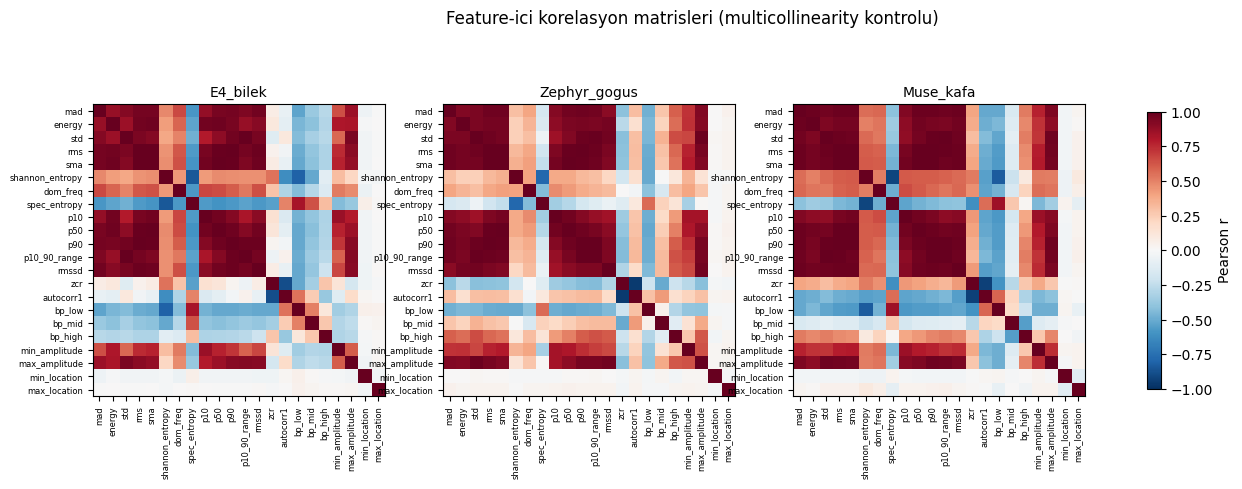

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, t) in zip(axes, DEVICES.items()):
    im = ax.imshow(multicollinearity_summary[name]['corr_matrix'].values, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(len(FEATURE_POOL))); ax.set_yticks(range(len(FEATURE_POOL)))
    ax.set_xticklabels(FEATURE_POOL, rotation=90, fontsize=6)
    ax.set_yticklabels(FEATURE_POOL, fontsize=6)
    ax.set_title(name, fontsize=10)
fig.colorbar(im, ax=axes, shrink=0.8, label='Pearson r')
plt.suptitle('Feature-ici korelasyon matrisleri (multicollinearity kontrolu)', y=1.03)
plt.show()


In [20]:
importance_summary = {}
t0 = time.time()
for name, t in DEVICES.items():
    for tgt in ['MET', 'EE']:
        importance_summary[(name, tgt)] = loso_feature_importance(t, tgt)
        print(f"  {name} x {tgt} tamam ({time.time()-t0:.0f} sn)")
print("\nLOSO feature importance hesaplandi.")


  E4_bilek x MET tamam (518 sn)
  E4_bilek x EE tamam (1002 sn)
  Zephyr_gogus x MET tamam (1506 sn)
  Zephyr_gogus x EE tamam (1985 sn)
  Muse_kafa x MET tamam (2451 sn)
  Muse_kafa x EE tamam (2884 sn)

LOSO feature importance hesaplandi.


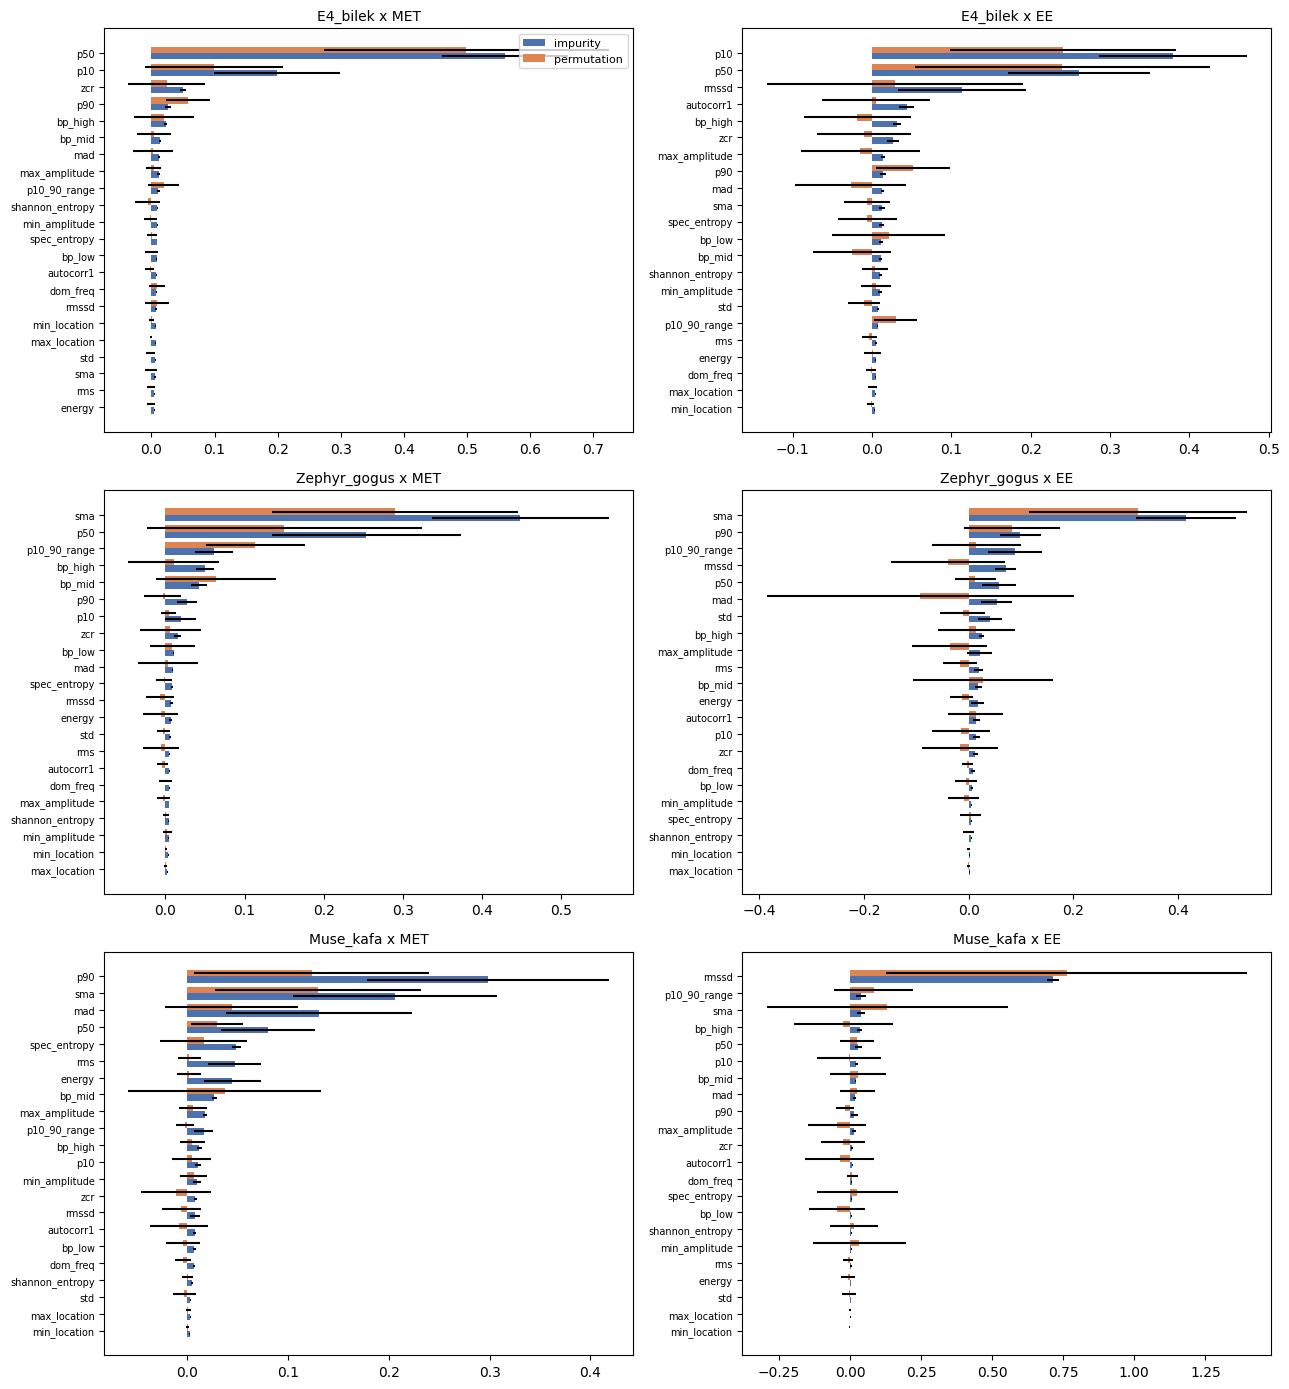

In [21]:
fig, axes = plt.subplots(3, 2, figsize=(13, 14))
for row, name in enumerate(DEVICES.keys()):
    for col, tgt in enumerate(['MET', 'EE']):
        ax = axes[row, col]
        imp = importance_summary[(name, tgt)].sort_values('impurity_mean', ascending=True)
        y = np.arange(len(imp))
        ax.barh(y - 0.19, imp['impurity_mean'], height=0.38, xerr=imp['impurity_std'], label='impurity', color='#4C72B0')
        ax.barh(y + 0.19, imp['permutation_mean'].fillna(0), height=0.38, xerr=imp['permutation_std'].fillna(0),
                label='permutation', color='#DD8452')
        ax.set_yticks(y); ax.set_yticklabels(imp['feature'], fontsize=7)
        ax.set_title(f"{name} x {tgt}", fontsize=10)
        if row == 0 and col == 0:
            ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Yorumlama notu:** Kod çalıştırıldığında yukarıdaki tablo ve grafikler gerçek sayılarla dolacaktır.
Tartışma bölümünde şu noktalara dikkat edilmelidir: impurity-based ve permutation-based sıralamalar önemli
ölçüde farklıysa (özellikle multicollinearity tablosunda `|r|>0.9` çıkan feature çiftleri arasında), bu
farkın **çok değil zayıf feature'ı işaret etmediği**, sadece impurity-based yöntemin korele feature'lar
arasında önemi bölüştürdüğü şeklinde yorumlanmalıdır — permutation-based sonuç daha güvenilir kabul
edilmelidir.


# ADIM 4 — Cihazlar arası karşılaştırmalı özet (betimsel)

Her feature için üç cihazdaki Spearman korelasyonu (MET ve EE) ile ortalama RF (impurity) importance'ı
yan yana gösteren tek bir özet tablo. Bu tablo hangi feature'ların cihazdan bağımsız tutarlı davrandığını,
hangilerinin cihaza özgü farklılaştığını görmeyi sağlar — **yalnızca yorumlama amaçlı, feature eleme amaçlı
değil.**


In [22]:
def build_cross_device_summary():
    rows = []
    for feat in FEATURE_POOL:
        row = {'feature': feat}
        imps = []
        for name in DEVICE_NAMES:
            met_seg = feature_analysis_summary[name]['MET_segment'].set_index('feature')
            ee_seg = feature_analysis_summary[name]['EE_segment'].set_index('feature')
            row[f'{name}_spearman_MET'] = met_seg.loc[feat, 'spearman_r'] if feat in met_seg.index else np.nan
            row[f'{name}_spearman_EE'] = ee_seg.loc[feat, 'spearman_r'] if feat in ee_seg.index else np.nan
            for tgt in ['MET', 'EE']:
                imp_tab = importance_summary[(name, tgt)].set_index('feature')
                if feat in imp_tab.index:
                    imps.append(imp_tab.loc[feat, 'impurity_mean'])
        row['mean_RF_importance_3device'] = float(np.nanmean(imps)) if imps else np.nan
        rows.append(row)
    return pd.DataFrame(rows).sort_values('mean_RF_importance_3device', ascending=False).reset_index(drop=True)

cross_device_summary = build_cross_device_summary()
print("=== Cihazlar arasi karsilastirmali ozet (betimsel, feature eleme icin degil) ===")
print(cross_device_summary.round(3).to_string(index=False))


=== Cihazlar arasi karsilastirmali ozet (betimsel, feature eleme icin degil) ===
        feature  E4_bilek_spearman_MET  E4_bilek_spearman_EE  Zephyr_gogus_spearman_MET  Zephyr_gogus_spearman_EE  Muse_kafa_spearman_MET  Muse_kafa_spearman_EE  mean_RF_importance_3device
            p50                  0.663                 0.850                      0.703                     0.892                   0.739                  0.873                       0.207
            sma                  0.653                 0.839                      0.702                     0.894                   0.735                  0.876                       0.188
          rmssd                  0.645                 0.840                      0.699                     0.881                   0.724                  0.882                       0.153
            p10                  0.670                 0.848                      0.710                     0.898                   0.753                  0.874   

# ADIM 5 — İkinci notebook'a aktarılacak veri

Her cihaz için `subject_id, activity, MET, EE, gerekli metadata` ve **tam feature havuzundaki tüm
kolonlar (hiçbiri elenmemiş)** içeren temiz bir DataFrame oluşturulur. Üç cihaz için de kolon isimleri
ve sayısı birebir aynıdır (metadata/device kolonları hariç).

Tek bir ana çıktı üretilir:

- **`windowed_feature_data`** — üç cihaz için de aynı, tam zengin feature havuzunu içeren temiz
  window-level dataset (`device, subject, activity, MET, EE`, demografik metadata, 22 feature kolonu).

Adım 2–4'teki exploratory tablolar ayrı bir çıktı olarak saklanır (`feature_analysis_summary`) — bu,
Notebook 2'nin modelleme girdisi **değildir**, yalnızca raporlama/discussion amaçlıdır.

Notebook 2'de: tüm cihazlar aynı tam feature setiyle (feature seçimi olmadan) LOSO ile modellenecektir.


In [23]:
def assemble_windowed_feature_data():
    parts = []
    for name, t in DEVICES.items():
        d = t.copy()
        d.insert(0, 'device', name)
        col_order = ['device', 'subject', 'activity', 'MET', 'EE'] + METADATA_COLS + FEATURE_POOL
        parts.append(d[col_order])
    out = pd.concat(parts, ignore_index=True)
    return out

windowed_feature_data = assemble_windowed_feature_data()
print("windowed_feature_data:", windowed_feature_data.shape)
print("kolonlar:", list(windowed_feature_data.columns))
windowed_feature_data.head()


windowed_feature_data: (2361, 33)
kolonlar: ['device', 'subject', 'activity', 'MET', 'EE', 'Weight', 'Height', 'BMI', 'Age', 'Sex', 'FFM', 'mad', 'energy', 'std', 'rms', 'sma', 'shannon_entropy', 'dom_freq', 'spec_entropy', 'p10', 'p50', 'p90', 'p10_90_range', 'rmssd', 'zcr', 'autocorr1', 'bp_low', 'bp_mid', 'bp_high', 'min_amplitude', 'max_amplitude', 'min_location', 'max_location']


,device,subject,activity,MET,EE,Weight,Height,BMI,Age,Sex,...,rmssd,zcr,autocorr1,bp_low,bp_mid,bp_high,min_amplitude,max_amplitude,min_location,max_location
0,E4_bilek,P01,Sit,1.0,1.241849,70.6,166,24.7,29,0,...,0.003901,0.267848,0.475678,0.035347,0.042400,0.057832,0.000012,0.021640,0.825000,0.341146
1,E4_bilek,P01,Sit,1.0,1.241849,70.6,166,24.7,29,0,...,0.003175,0.149036,0.411492,0.059399,0.083574,0.082300,0.000012,0.015766,0.325000,0.294271
2,E4_bilek,P01,Sit,1.0,1.241849,70.6,166,24.7,29,0,...,0.003144,0.169880,0.431881,0.058619,0.073283,0.077413,0.000007,0.015468,0.921875,0.553125
3,E4_bilek,P01,Sit,1.0,1.241849,70.6,166,24.7,29,0,...,0.003336,0.201668,0.498050,0.050004,0.056127,0.062436,0.000007,0.017611,0.421875,0.548958
4,E4_bilek,P01,Sit,1.0,1.241849,70.6,166,24.7,29,0,...,0.004292,0.349661,0.416388,0.021903,0.030031,0.039921,0.000011,0.020438,0.299479,0.655208


In [24]:
print("=== device basina satir/ozne/feature kontrolu (son dogrulama) ===")
chk = windowed_feature_data.groupby('device').agg(
    satir=('subject', 'size'),
    ozne=('subject', 'nunique'),
    EE_etiketli=('EE', lambda s: int(s.notna().sum())),
)
chk['feature_sayisi'] = len(FEATURE_POOL)
print(chk.to_string())
assert windowed_feature_data.groupby('device').apply(lambda g: tuple(g.columns)).nunique() == 1, \
    "Cihazlar arasinda kolon seti farkli -- adalet ilkesi ihlal edilmis olabilir!"
print("\nDogrulandi: uc cihaz da ayni kolon setine sahip.")


=== device basina satir/ozne/feature kontrolu (son dogrulama) ===
              satir  ozne  EE_etiketli  feature_sayisi
device                                                
E4_bilek        833    17          689              22
Muse_kafa       696    16          576              22
Zephyr_gogus    832    17          689              22

Dogrulandi: uc cihaz da ayni kolon setine sahip.


## Çıktıları kaydet

CSV yanında pickle ve parquet seçenekleri de sunulur:

- **CSV** — insan tarafından okunabilir, evrensel uyumluluk, ama dtype bilgisini kaybeder (özellikle
  `subject`/`activity` gibi kategorik kolonlar CSV'de string olarak geri okunur).
- **Pickle** — Python/pandas dtype'larını tam koruyarak en hızlı okuma/yazma; Notebook 2 aynı ortamda
  (Colab/Python) çalışacağı için önerilen birincil format budur.
- **Parquet** — sıkıştırılmış, sütun bazlı, büyük veri ve tip-güvenli okuma için ideal; Colab'de `pyarrow`
  kurulu gelmeyebileceği için burada `pip install` satırı eklenmiştir.


In [25]:
!pip install -q pyarrow


In [26]:
import pickle

OUT_DIR = '/content/drive/MyDrive/PAWS/notebook1_outputs'
os.makedirs(OUT_DIR, exist_ok=True)

# --- ana modelleme girdisi ---
windowed_feature_data.to_csv(os.path.join(OUT_DIR, 'windowed_feature_data.csv'), index=False)
windowed_feature_data.to_pickle(os.path.join(OUT_DIR, 'windowed_feature_data.pkl'))
try:
    windowed_feature_data.to_parquet(os.path.join(OUT_DIR, 'windowed_feature_data.parquet'), index=False)
    parquet_ok = True
except Exception as e:
    print("parquet yazilamadi (pyarrow sorunu olabilir):", e)
    parquet_ok = False

# --- exploratory / raporlama amacli cikti (Notebook 2'nin modelleme girdisi DEGIL) ---
with open(os.path.join(OUT_DIR, 'feature_analysis_summary.pkl'), 'wb') as f:
    pickle.dump({
        'feature_analysis_summary': feature_analysis_summary,
        'multicollinearity_summary': multicollinearity_summary,
        'importance_summary': importance_summary,
        'cross_device_summary': cross_device_summary,
    }, f)
cross_device_summary.to_csv(os.path.join(OUT_DIR, 'cross_device_summary.csv'), index=False)

print("Kaydedildi ->", OUT_DIR)
print("  windowed_feature_data.csv / .pkl" + (" / .parquet" if parquet_ok else " (parquet basarisiz)"))
print("  feature_analysis_summary.pkl (exploratory, modelleme girdisi degil)")
print("  cross_device_summary.csv (Adim 4 ozet tablosu)")


Kaydedildi -> /content/drive/MyDrive/PAWS/notebook1_outputs
  windowed_feature_data.csv / .pkl / .parquet
  feature_analysis_summary.pkl (exploratory, modelleme girdisi degil)
  cross_device_summary.csv (Adim 4 ozet tablosu)


---

## Notebook 1 → Notebook 2 arayüzü (interface) — özet tanım

**Dosyalar:**

| Dosya | İçerik | Notebook 2'de kullanımı |
|---|---|---|
| `windowed_feature_data.csv` / `.pkl` / `.parquet` | Modelleme girdisi | **Evet** — doğrudan LOSO modelleme için okunur |
| `feature_analysis_summary.pkl` | Korelasyon/Kruskal-Wallis/importance tabloları | **Hayır** — sadece discussion/interpretation için |
| `cross_device_summary.csv` | Adım 4 özet tablosu | **Hayır** — sadece raporlama için |

**`windowed_feature_data` kolonları (satır birimi: pencere/window):**

- `device` — `E4_bilek` / `Zephyr_gogus` / `Muse_kafa` (string)
- `subject` — özne ID, ör. `P01` (string)
- `activity` — `Sit / Stand / Cycle1 / Cycle2 / Run1 / Run2` (string)
- `MET` — hedef değişken 1 (float)
- `EE` — hedef değişken 2, kcal/dk (float, VO2 eksik olan bazı özne-aktivite kombinasyonlarında NaN
  olabilir — Notebook 2 EE modellemesi öncesi `dropna(subset=['EE'])` uygulamalıdır, tıpkı referans
  notebook'taki `_prep` fonksiyonunun yaptığı gibi)
- `Weight, Height, BMI, Age, Sex, FFM` — demografik metadata (float/int), feature havuzuna dahil değildir
- **22 feature kolonu** (`FEATURE_POOL` ile birebir aynı sırada): `mad, energy, std, rms, sma,
  shannon_entropy, dom_freq, spec_entropy, p10, p50, p90, iqr, rmssd, zcr, autocorr1, bp_low, bp_mid,
  bp_high, min_amplitude, max_amplitude, min_location, max_location`

**Varsayımlar / dikkat edilmesi gerekenler:**

1. **Feature seçimi yoktur.** Notebook 2, `windowed_feature_data`'daki 22 feature kolonunun tamamını
   olduğu gibi kullanacaktır. `feature_analysis_summary`'den hiçbir eleme kararı Notebook 2'ye
   aktarılmayacaktır.
2. **Pencereleme:** `WINDOW_SIZE=60` sn, `OVERLAP=0.5` — üç cihazda da aynı. Bu parametre Notebook 1'in
   başında tek yerden değiştirilebilir; değiştirilirse Notebook 1 yeniden çalıştırılıp
   `windowed_feature_data` yeniden üretilmelidir.
3. **LOSO grubu:** Notebook 2'de `LeaveOneGroupOut` için grup değişkeni `subject` kolonu olmalıdır —
   referans notebook'taki implementasyonla birebir aynı mantık.
4. **EE eksik değerler:** `EE` kolonunda NaN olan satırlar (VO2 verisi eksik özneler, ör. `P10` tüm
   cihazlarda, `Muse_kafa`'da ayrıca `P02`) EE modellemesi öncesi düşürülmelidir; MET modellemesi bu
   satırları etkilemez.
5. **Cihazlar arası segment sayısı farklı olabilir** (özellikle `Muse_kafa` diğer iki cihazdan bir özne
   eksik olabilir) — bu, cihaz kıyaslamalarında "ortak segment" filtrelemesi gerekip gerekmediğine dair bir
   modelleme kararıdır ve Notebook 2'nin kapsamındadır, Notebook 1 bu kararı vermez.
6. **Cross-device karşılaştırma caveat'leri** (Adım 2 sonrası markdown'da detaylandırıldı): `dom_freq`,
   `spec_entropy`, `bp_low/mid/high`, `min_location/max_location` ve genlik-tabanlı feature'ların mutlak
   ölçeği cihazlar arasında donanımsal farklardan (bandpass üst kesimi, kalibrasyon, örnekleme hızı)
   etkilenebilir. Bu farklar feature'ları eleme gerekçesi değildir, sadece yorumlama sırasında akılda
   tutulmalıdır.

Notebook 2'nin kodu bu notebook'ta yazılmamıştır; yalnızca yukarıdaki arayüz tanımına göre
`windowed_feature_data`'yı okuyup model eğitimi + final LOSO değerlendirmesini gerçekleştirecektir.
